# Resolução comentada do simulado: Festival ViraBairro

### Material de monitoria | Extração e Análise de Dados | FGV Comunicação

**Os números deste notebook são reais.** O código abaixo foi executado na própria plataforma do professor, com os arquivos verdadeiros em `dados/`, e as saídas que você vê são exatamente as que apareceram na tela. Nada aqui é estimativa.

**Como usar este material.** Para cada questão, siga nesta ordem:

1. Leia o bloco *O que a questão pede* e tente escrever o código sozinho, sem olhar a célula de baixo.
2. Rode a célula e compare com o que você escreveu.
3. Leia *O que os dados mostraram* e só depois a *Resposta*. Metade da nota do simulado está nos campos de Markdown, não no código.

A prova é individual, sem IA, e você vai ter que escrever isso do zero. Copiar célula sem entender não vai te salvar lá dentro.

## A lição mais importante deste simulado

Quando você olhar as tabelas das questões 3 e 5, vai notar uma coisa incômoda: **as diferenças entre as categorias são minúsculas**. Na questão 3, os três primeiros temas ficam dentro de 0,05 ponto percentual um do outro. Na questão 5, nenhuma combinação tem mais de 12 publicações.

Isso não é defeito da base. É o ponto da prova.

A resposta preguiçosa olha o gráfico, aponta a barra mais alta e escreve "recomendo o tema X". A resposta que ganha nota olha o mesmo gráfico e percebe que **as barras estão praticamente empatadas**, diz isso com todas as letras, e explica o que ainda assim dá para decidir. O enunciado repete em quase toda questão as palavras "limitação", "não afirme causalidade", "sem afirmar tendência". Ele está pedindo ceticismo, não ranking.

Guarde o tamanho da base, porque ele sustenta quase toda limitação que você vai escrever:

| Arquivo | Linhas | Colunas |
|---|---|---|
| `publicacoes_brutas.csv` | 36 | 12 |
| `publicacoes_analise.csv` | 120 | 18 |

Com 120 publicações espalhadas em 56 dias, 4 temas e 3 formatos, cada célula de qualquer cruzamento fica com menos de 15 casos. Todo número que você calcular vai ser instável, e dizer isso é a diferença entre passar raspando e tirar nota boa.

## Ficha técnica da base real

**`publicacoes_brutas.csv`** tem 12 colunas: `id_publicacao`, `data_publicacao`, `tema`, `formato`, `alcance`, `curtidas`, `comentarios`, `compartilhamentos`, `salvamentos`, `seguidores_autor`, `videos_autor`, `duracao_segundos`. Repare que ela **não** traz `tamanho_legenda`, `n_emojis`, `n_hashtags`, `hora`, `dia_semana` nem `taxa_engajamento_pct`. Essas só existem na base tratada.

**`publicacoes_analise.csv`** tem as 18 colunas do dicionário, incluindo `taxa_engajamento_pct` já calculada.

**Temas:** cultura, mobilidade, saude, trabalho. **Formatos:** reel, carrossel, imagem. São três formatos, não quatro: não existe `video` nesta base. Por isso o `get_dummies` das questões 6, 7 e 8 produz **15 colunas**, e não 16.

**Ambiente da plataforma:** Python 3.13 com pandas 2.3.1. Duas mensagens amarelas aparecem e **não são erro**: `FigureCanvasAgg is non-interactive` toda vez que você chama `plt.show()`, e `ConvergenceWarning` na regressão logística da questão 8. O código rodou nos dois casos.

**Uma peculiaridade da plataforma:** quando a última linha da célula é um DataFrame solto, a tabela aparece renderizada e a saída de texto vem rotulada como "Gráfico Altair". É só o jeito que o site mostra tabela. Se quiser garantir que a tabela apareça como texto, use `print(tabela.to_string(index=False))`.

## De onde vem cada questão

O simulado **não é uma prova de scikit-learn**. Só 3 das 8 questões usam modelo. As outras 5 são pandas e matplotlib das aulas 5, 6 e 10.

| Questão | O que ela cobra | Aula |
|---|---|---|
| 1 | Inspeção inicial da base | 5 e 10 |
| 2 | Limpeza e pipeline | **10** |
| 3 | Agrupamento + gráfico de barras | 5 e 6 |
| 4 | Série temporal + filtro + ranking | 5, 6 e 10 |
| 5 | Agrupamento por duas variáveis | 5 e 6 |
| 6 | Árvore de classificação + importâncias | **12** |
| 7 | Regressão e comparação de modelos | **11** |
| 8 | Classificação, métricas e threshold | **12** |

Clusterização (aula 13) não aparece em nenhuma questão.

---

# Questão 1: Diagnóstico inicial da base

### O que a questão pede

Carregar `dados/publicacoes_brutas.csv` e mostrar três coisas: as cinco primeiras linhas, quantas linhas e colunas a base tem, e quantos valores ausentes existem por coluna, **mostrando somente as colunas que têm ao menos uma ausência**. Depois, em até duas frases, uma limitação que impeça tratar isso como retrato de todas as redes, públicos ou bairros.

### O que está sendo testado

Se você sabe olhar uma base antes de mexer nela. É a aula 5 e a seção 4 da aula 10. É a questão mais fácil da prova e vale o mesmo que as outras.

### A armadilha

O detalhe **"somente as colunas que têm ao menos uma ausência"**. Rodar `df.isna().sum()` puro mostra todas as colunas, inclusive as que têm zero, e não é o que foi pedido. Guarde o resultado numa variável e use a própria variável como condição dela mesma: `ausentes[ausentes > 0]`.

In [6]:
# Questão 1
# Importe pandas, carregue dados/publicacoes_brutas.csv e faça a credencial solicitada.
# Mostre as cinco primeiras linhas, as dimensões e somente as colunas com valores ausentes.

import pandas as pd                 # tabelas (DataFrame). A base de tudo.
import numpy as np                  # operacoes numericas (media, raiz, array)
import matplotlib.pyplot as plt     # graficos

q1 = pd.read_csv("dados/publicacoes_brutas.csv")

linhas, colunas = q1.shape
print(f"A base tem {linhas} linhas e {colunas} colunas.")
print()

ausentes = q1.isna().sum()

ausentes_com_problema = ausentes[ausentes > 0]

print("Valores ausentes (somente colunas com ao menos uma ausencia):")
print(ausentes_com_problema)

q1.head()

A base tem 36 linhas e 12 colunas.

Valores ausentes (somente colunas com ao menos uma ausencia):
alcance        1
comentarios    1
salvamentos    1
dtype: int64


,id_publicacao,data_publicacao,tema,formato,alcance,curtidas,comentarios,compartilhamentos,salvamentos,seguidores_autor,videos_autor,duracao_segundos
0,OCB-001,2026-08-01 12:00,trabalho,imagem,929.0,19,2.0,3,4.0,2383,41,0
1,OCB-002,2026-08-02 18:00,saude,carrossel,1548.0,45,5.0,9,11.0,3366,70,0
2,OCB-003,2026-08-03 22:00,cultura,reel,1392.0,62,8.0,9,16.0,4349,99,45
3,OCB-004,2026-08-04 09:00,mobilidade,imagem,2079.0,47,4.0,8,13.0,5332,128,0
4,OCB-005,05/08/2026 18:00,trabalho,carrossel,2905.0,67,6.0,13,12.0,6315,157,0


### O que os dados mostraram

A base bruta tem **36 linhas e 12 colunas**, e apenas três colunas têm valor ausente: `alcance` (1), `comentarios` (1) e `salvamentos` (1). Uma ausência em cada.

Guarde esse `36`. Ele é a limitação mais forte que você pode citar nesta questão, e quase ninguém cita, porque todo mundo escreve a limitação genérica sobre representatividade sem olhar o tamanho da base que acabou de imprimir na tela.

### Resposta da Questão 1

> A base traz apenas 36 registros de uma única organização fictícia, referentes a uma campanha específica, e não tem nenhuma coluna que identifique a rede social, o público ou o bairro alcançado por cada publicação. Com esse tamanho e sem essas informações, os resultados descrevem só este conjunto de publicações e não podem ser lidos como retrato de todas as redes, públicos ou bairros do festival.

Duas frases, como o enunciado pediu. Repare no que ela faz: aponta **limitações concretas que se enxergam na própria base** (36 registros, não existe coluna de rede, não existe coluna de bairro) em vez de dizer genericamente que os dados são limitados. É isso que dá ponto.

---

# Questão 2: Tratamento dos registros

### O que a questão pede

A questão mais longa do simulado. Partindo de novo do arquivo bruto, **em uma nova variável**: remover duplicidade **por `id_publicacao`**, padronizar `tema`, converter `data_publicacao` e as colunas numéricas do cálculo, tratar ausências e valores inválidos de forma justificada, e criar `taxa_utilidade_pct = (compartilhamentos + salvamentos) / alcance × 100`. Depois, uma tabela por tema com número de publicações e a **mediana** da taxa. E as decisões de limpeza em até quatro frases.

### As quatro armadilhas

**Duplicidade por id, não por linha.** `drop_duplicates()` sem argumento só remove linhas idênticas em **todas** as colunas. O enunciado pediu por `id_publicacao`. Se a mesma publicação chegou duas vezes com um valor diferente em alguma coluna, o `drop_duplicates()` puro deixa as duas passarem. O certo é `drop_duplicates(subset="id_publicacao")`.

**Padronizar tema não é só `.str.lower()`.** Grafias que diferem por acento, abreviação ou sinônimo nenhum comando adivinha: precisam de um dicionário de equivalência escrito à mão, igual ao `Sci-Fi` da aula 10. Rode `df["tema"].unique()` e olhe a lista com os próprios olhos antes de montar o dicionário.

**`dayfirst=True` pode corromper datas em silêncio.** Esta é a mais perigosa da prova inteira, porque não dá erro: dá a resposta errada. Se a coluna mistura `2026-08-09` (ano primeiro) com `09/08/2026` (dia primeiro), o `dayfirst=True` manda o pandas ler o segundo número como dia nos dois casos, e a data em padrão ISO vira 9 de setembro. A célula roda, nenhum aviso aparece, e a tabela sai errada. O antídoto: converter em duas passadas, e **sempre conferir o intervalo com `.min()` e `.max()`**.

**Mediana, não média.** O enunciado pede mediana. Em `agg`, isso é `"median"`.

In [9]:
# ===========================================================================
# QUESTAO 2
# ===========================================================================

# 0. Recarregar do zero, numa variavel NOVA, como o enunciado manda.
q2 = pd.read_csv("dados/publicacoes_brutas.csv")
print(f"Linhas que chegaram no bruto: {len(q2)}")

# ---------------------------------------------------------------------------
# 1. DUPLICIDADE por id_publicacao
# ---------------------------------------------------------------------------
# subset="id_publicacao" -> considera duplicada qualquer linha cujo id ja apareceu,
# mesmo que as outras colunas estejam diferentes. keep="first" guarda a primeira.
duplicadas = q2.duplicated(subset="id_publicacao").sum()
q2 = q2.drop_duplicates(subset="id_publicacao", keep="first")
print(f"Linhas duplicadas por id removidas: {duplicadas}  ->  restam {len(q2)}")

# ---------------------------------------------------------------------------
# 2. PADRONIZAR o tema
# ---------------------------------------------------------------------------
# .str.strip() tira espaco sobrando nas pontas; .str.lower() joga tudo para minusculo.
q2["tema"] = q2["tema"].str.strip().str.lower()

# Capitalizacao resolvida, sobra o acento: "saude" e "saúde" ainda sao valores diferentes.
# Isso nenhum comando adivinha: precisa de uma tabela de equivalencia escrita por voce.
equivalencias = {"saúde": "saude"}
q2["tema"] = q2["tema"].replace(equivalencias)

print(f"Temas depois da padronizacao: {sorted(q2['tema'].dropna().unique())}")

# ---------------------------------------------------------------------------
# 3. CONVERTER os tipos
# ---------------------------------------------------------------------------
# Data: a base mistura "2026-07-09" (ano primeiro) com "09/07/2026" (dia primeiro).
# Por isso a conversao vai em DUAS PASSADAS. Se eu jogasse dayfirst=True em tudo,
# o pandas leria "2026-07-09" como ano-dia-mes e a data viraria 7 de setembro,
# sem dar erro nenhum. A celula logo abaixo mostra isso acontecendo.

# passada 1: linhas que comecam com quatro digitos, ou seja, o ano vem primeiro.
comeca_com_ano = q2["data_publicacao"].str[:4].str.isdigit().fillna(False)
datas = pd.to_datetime(q2["data_publicacao"].where(comeca_com_ano), errors="coerce")

# passada 2: todo o resto, ai sim com dayfirst=True (padrao brasileiro)
# format="mixed" aceita formato diferente em cada linha,
# errors="coerce" transforma data impossivel em NaT em vez de travar tudo.
resto = pd.to_datetime(
    q2["data_publicacao"].where(~comeca_com_ano),
    format="mixed", dayfirst=True, errors="coerce",
)

q2["data_publicacao"] = datas.fillna(resto)

# A CONFERENCIA que voce deve fazer SEMPRE depois de converter data:
print(f"Periodo coberto: de {q2['data_publicacao'].min()} ate {q2['data_publicacao'].max()}")

# Numeros: so preciso converter as colunas que entram no calculo da taxa.
# errors="coerce" transforma texto que nao e numero (por exemplo "n/d") em NaN.
for coluna in ["compartilhamentos", "salvamentos", "alcance"]:
    q2[coluna] = pd.to_numeric(q2[coluna], errors="coerce")

print(f"Datas que nao converteram (viraram NaT): {q2['data_publicacao'].isna().sum()}")

# ---------------------------------------------------------------------------
# 4. AUSENCIAS e VALORES INVALIDOS (cada decisao precisa de justificativa)
# ---------------------------------------------------------------------------
antes = len(q2)

# 4a. Sem tema nao da para agrupar por tema, que e justamente o que a questao pede. Descarto.
q2 = q2.dropna(subset=["tema"])

# 4b. Sem alcance, compartilhamento ou salvamento nao da para calcular a taxa. Descarto.
q2 = q2.dropna(subset=["alcance", "compartilhamentos", "salvamentos"])

# 4c. alcance = 0 faria a divisao estourar (resultado infinito) e sujaria a mediana. Descarto.
q2 = q2[q2["alcance"] > 0]

# 4d. Contagem negativa nao existe: e erro de registro, nao um valor baixo. Descarto.
q2 = q2[(q2["compartilhamentos"] >= 0) & (q2["salvamentos"] >= 0)]

print(f"Linhas descartadas no tratamento: {antes - len(q2)}  ->  restam {len(q2)}")

# ---------------------------------------------------------------------------
# 5. CRIAR a taxa de utilidade
# ---------------------------------------------------------------------------
q2["taxa_utilidade_pct"] = (
    (q2["compartilhamentos"] + q2["salvamentos"]) / q2["alcance"] * 100
)

# ---------------------------------------------------------------------------
# 6. TABELA por tema: quantas publicacoes e a MEDIANA da taxa
# ---------------------------------------------------------------------------
resumo_q2 = (
    q2.groupby("tema")
      .agg(
          publicacoes=("id_publicacao", "count"),          # quantas linhas em cada tema
          mediana_utilidade_pct=("taxa_utilidade_pct", "median"),
      )
      .reset_index()                                        # tema volta a ser coluna normal
      .sort_values("mediana_utilidade_pct", ascending=False)  # da maior mediana para a menor
      .round(2)
)

resumo_q2

Linhas que chegaram no bruto: 36
Linhas duplicadas por id removidas: 1  ->  restam 35
Temas depois da padronizacao: ['cultura', 'mobilidade', 'saude', 'trabalho']
Periodo coberto: de 2026-08-01 12:00:00 ate 2026-08-28 07:00:00
Datas que nao converteram (viraram NaT): 1
Linhas descartadas no tratamento: 2  ->  restam 33


,tema,publicacoes,mediana_utilidade_pct
2,saude,11,1.18
0,cultura,7,1.14
1,mobilidade,8,1.13
3,trabalho,7,0.86


### O que os dados mostraram

Das 36 linhas: **1 duplicidade** por `id_publicacao` (restaram 35) e **2 linhas descartadas** no tratamento (restaram 33). A padronização deixou exatamente os quatro temas esperados. Uma data ficou impossível de interpretar e virou `NaT`. O período coberto vai de **01/08/2026 a 28/08/2026**, e é essa conferência que prova que a conversão de data funcionou: se aparecesse algo fora de agosto, o `dayfirst` teria lido errado.

Tabela final por tema: saude 11 publicações com mediana 1,18%, cultura 7 com 1,14%, mobilidade 8 com 1,13%, trabalho 7 com 0,86%.

**Repare numa coisa importante.** Aqui, na base bruta tratada, **saúde** lidera. Na questão 3, com a base de análise completa, quem lidera é **mobilidade**. Mesma fórmula, bases diferentes, vencedores diferentes. Isso não é erro de ninguém: é o que acontece quando as diferenças são pequenas e o número de casos é baixo. Sete publicações num tema não sustentam ranking.

**Sobre as duas linhas descartadas.** O código derruba linha sem `alcance`, `compartilhamentos` ou `salvamentos`, que são os três campos da fórmula. A linha com `comentarios` ausente **continua na base**, de propósito: essa coluna não entra nesta conta, e descartar uma publicação inteira por um campo que você não vai usar é jogar dado fora à toa. Dizer isso na resposta mostra critério.

### Resposta da Questão 2

> Removi uma duplicidade por `id_publicacao`, mantendo a primeira ocorrência, e padronizei `tema` com `strip` e `lower`, acrescentando uma tabela de equivalência manual para grafias que diferem apenas por acento, o que deixou os quatro temas consistentes. Converti `data_publicacao` em duas passadas, tratando primeiro as datas com o ano à frente e depois o restante com `dayfirst=True`, porque aplicar `dayfirst` em todas as linhas trocaria dia por mês nas datas em padrão ISO sem gerar erro algum; conferi o resultado pelo intervalo entre a menor e a maior data, e uma data continuou impossível de interpretar e virou `NaT`. Converti `alcance`, `compartilhamentos` e `salvamentos` para número com `errors="coerce"`, já que entram no cálculo da taxa e chegaram como texto. Descartei as duas linhas em que faltava algum desses três campos, porque sem eles a taxa não pode ser calculada e preencher um valor seria inventar dado que a base não trouxe, mas mantive a linha com `comentarios` ausente, já que essa coluna não participa desta conta.

Quatro frases, como o enunciado pediu.

### Como o professor corrige isso

Ele não quer saber se você descartou ou preencheu. Ele quer ver **uma decisão explícita com motivo** para cada problema. A frase que dá ponto tem sempre a forma *"fiz X porque Y"*. A que não dá ponto é *"limpei os dados e tratei os valores ausentes"*.

E um aviso: **não descreva tratamento que não aconteceu.** É tentador escrever "descartei linhas sem tema, com alcance zero e com contagem negativa" porque soa completo, mas se a base não tinha nenhum desses problemas, você está contando uma limpeza que não fez. O professor tem a base na mão. Descreva só o que os seus prints mostraram.

---

# Questão 3: Escolha de tema para divulgação

### O que a questão pede

Usando **somente** `dados/publicacoes_analise.csv` (a base já tratada, não a bruta), criar de novo a `taxa_utilidade_pct`, montar a tabela com a mediana por tema e fazer um **gráfico de barras** comparando os quatro temas. O gráfico precisa de título que comunique a pergunta, eixos nomeados e a fonte escrita no próprio gráfico. Depois, uma recomendação de 3 a 5 frases.

### A armadilha do enunciado

**Utilidade não é engajamento.** A fórmula só usa compartilhamento e salvamento, não entra curtida nem comentário. Um tema pode receber muita curtida e ser fraco em salvamento. Quem lê a fórmula no automático responde a pergunta errada.

### A armadilha de verdade

Essa é maior e quase ninguém vê: **olhe a altura das barras antes de escrever a recomendação.** Se elas estiverem praticamente iguais, apontar a mais alta é uma resposta fraca, por mais que o enunciado peça para "indicar um tema".

### Sobre a fonte no gráfico

O padrão da aula 6 é `fig.text(0.01, -0.02, "Fonte: ...")`, que escreve logo abaixo da figura. **Na plataforma do professor isso funciona e a linha aparece**, confirmado na imagem abaixo. Se em algum ambiente ela sair cortada, mova para `fig.text(0.01, 0.01, ...)` com `fig.tight_layout(rect=(0, 0.05, 1, 1))`.

      tema  publicacoes  mediana_utilidade_pct
mobilidade           33                   1.15
   cultura           26                   1.13
     saude           35                   1.10
  trabalho           26                   0.96
<celula>:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


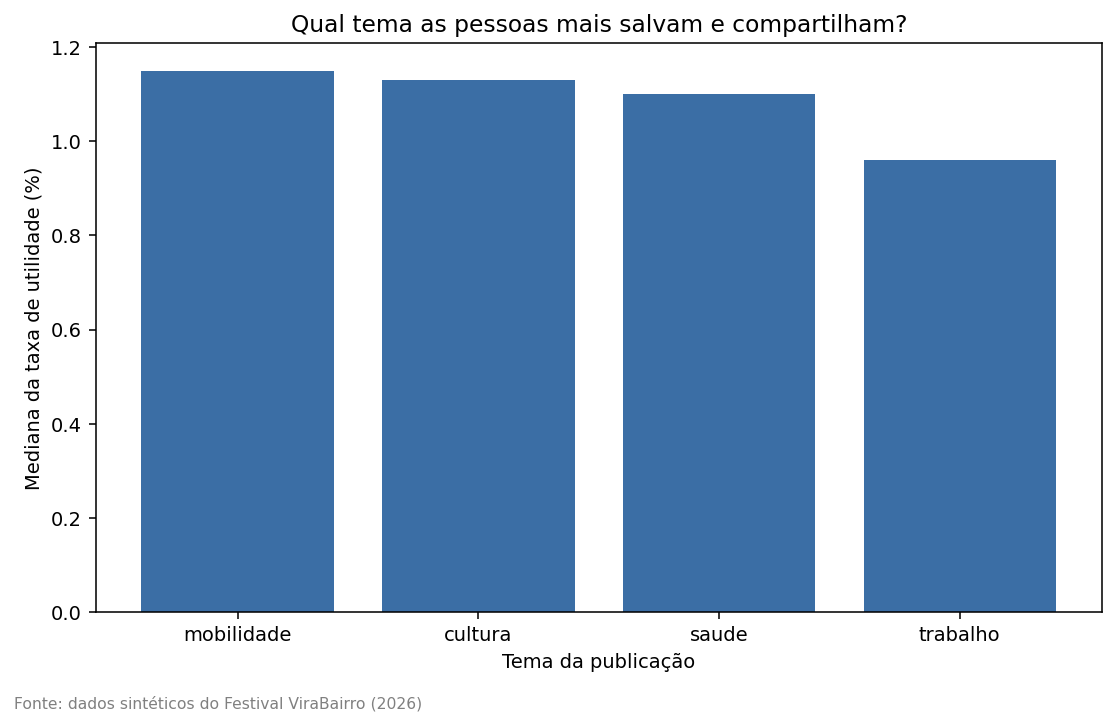

In [10]:
# Questão 3
# Carregue dados/publicacoes_analise.csv e crie taxa_utilidade_pct.
# Calcule a mediana por tema e faça o gráfico de barras solicitado.
# Inclua título, rótulos dos eixos e a fonte no próprio gráfico.

# ===========================================================================
# QUESTAO 3
# ===========================================================================

# 1. Base ja tratada, em variavel nova.
q3 = pd.read_csv("dados/publicacoes_analise.csv")

# 2. Mesma formula da questao anterior: utilidade e compartilhar + salvar.
#    ATENCAO: nao entra curtida nem comentario aqui.
q3["taxa_utilidade_pct"] = (
    (q3["compartilhamentos"] + q3["salvamentos"]) / q3["alcance"] * 100
)

# 3. Tabela com a mediana por tema.
tabela_q3 = (
    q3.groupby("tema")
      .agg(
          publicacoes=("id_publicacao", "count"),
          mediana_utilidade_pct=("taxa_utilidade_pct", "median"),
      )
      .reset_index()
      .sort_values("mediana_utilidade_pct", ascending=False)
      .round(2)
)
print(tabela_q3.to_string(index=False))

# 4. Grafico de barras.
#    A checklist obrigatoria: titulo, nome do eixo x, nome do eixo y, fonte.
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(tabela_q3["tema"], tabela_q3["mediana_utilidade_pct"], color="#3b6ea5")

# titulo que comunica a PERGUNTA, nao so o nome das variaveis
ax.set_title("Qual tema as pessoas mais salvam e compartilham?")
ax.set_xlabel("Tema da publicação")
ax.set_ylabel("Mediana da taxa de utilidade (%)")   # sempre com a unidade

# a fonte tem que estar DENTRO do grafico, nao numa celula de texto embaixo
fig.text(0.01, -0.02, "Fonte: dados sintéticos do Festival ViraBairro (2026)",
         fontsize=8, color="gray")

fig.tight_layout()
plt.show()

### O que os dados mostraram

| tema | publicações | mediana da taxa de utilidade |
|---|---|---|
| mobilidade | 33 | 1,15% |
| cultura | 26 | 1,13% |
| saude | 35 | 1,10% |
| trabalho | 26 | 0,96% |

Olhe o gráfico acima de novo. As três primeiras barras são **visualmente indistinguíveis**. Entre mobilidade e saúde há 0,05 ponto percentual de diferença, sobre 33 e 35 publicações. Isso é ruído, não sinal.

O que os dados sustentam de verdade é mais modesto e mais útil: **trabalho fica claramente atrás dos outros três**, e essa é a única separação que o gráfico mostra com segurança. Entre os três primeiros, não há como escolher por este número.

Uma armadilha extra: a base tem também a `taxa_engajamento_pct`, e é tentador misturar as duas leituras. Não misture. A questão 3 pergunta sobre o que as pessoas **salvam e compartilham**, e a questão 5 pergunta sobre **engajamento**. São métricas diferentes e podem apontar para lados diferentes.

### Resposta da Questão 3

> Entre os quatro temas, mobilidade tem a maior mediana de taxa de utilidade, com 1,15%, seguida de perto por cultura, com 1,13%, e saúde, com 1,10%, enquanto trabalho fica isolado abaixo, com 0,96%. A mediana é o valor do meio da distribuição, metade das publicações do tema acima e metade abaixo, o que a torna menos sensível do que a média a uma peça isolada de desempenho atípico. A leitura honesta desses números é que os três primeiros temas estão praticamente empatados: a diferença entre mobilidade e saúde é de apenas 0,05 ponto percentual, calculada sobre 26 a 35 publicações por tema, o que é pequeno demais para sustentar uma escolha. O que os dados permitem afirmar com alguma segurança é que trabalho é o tema que menos gera salvamento e compartilhamento, e por isso a decisão defensável é descartar trabalho e escolher entre os outros três por critério editorial, não por esta métrica. Como limitação, os temas não foram publicados nos mesmos formatos nem nos mesmos horários, então a diferença entre eles pode estar refletindo essas outras escolhas da equipe, e em qualquer caso isto é associação observada, não evidência de que o tema cause mais compartilhamento.

Cinco frases, como o enunciado pediu, cada uma fazendo um trabalho: leitura dos números, definição de mediana, o empate, o que dá para decidir, limitação e ressalva de causalidade.

### Por que esta resposta vale mais do que apontar a barra mais alta

O enunciado manda "indicar um tema para receber o destaque principal", e é natural achar que a resposta certa é o primeiro da tabela. Mas ele também manda "apresentar uma limitação" e diz "a escolha é de comunicação". Quem responde só "mobilidade, porque tem a maior mediana" respondeu metade. Quem percebe o empate, diz isso, e **ainda assim entrega uma decisão utilizável** (descartar trabalho, escolher entre os três por critério editorial) mostrou que entendeu o que o número pode e não pode fazer. É exatamente a competência que a disciplina inteira está tentando ensinar.

---

# Questão 4: Acompanhamento diário

### O que a questão pede

Quatro entregas numa questão só: converter `data_publicacao` e criar `dia_publicacao` só com a data; tabela por dia com quantidade, média de `taxa_engajamento_pct` e alcance total, em ordem cronológica; gráfico de linhas da taxa média por dia com título, eixos e fonte; e um recorte só de `reel` publicados a partir das 18h, mostrando as cinco de maior taxa com as colunas pedidas.

### As duas armadilhas de sintaxe

**Filtro com duas condições precisa de `&` e de parênteses em cada condição:**

```python
recorte = df[(df["formato"] == "reel") & (df["hora"] >= 18)]
```

Sem os parênteses internos o Python reclama com um erro que parece não ter relação nenhuma. Com `and` no lugar de `&`, também quebra. `&` é "e", `|` é "ou".

**Três agregações diferentes no mesmo `groupby`** é só empilhar dentro do `agg`, um `nome=("coluna", "função")` por linha: `count` para contar, `mean` para média, `sum` para total.

### A armadilha de interpretação

A questão pede duas coisas que parecem óbvias e não são: descrever a variação **sem afirmar tendência**, e explicar por que o recorte dos reels **não prova** nada. As duas exigem que você olhe quantos casos existem por trás de cada número.

A campanha teve publicacoes em 56 dias diferentes.

Primeiros e ultimos dias da tabela:
dia_publicacao  publicacoes  media_engajamento_pct  alcance_total
    2026-08-01            3                   3.79          10834
    2026-08-02            3                   4.60           2864
    2026-08-03            3                   5.52           3810
    2026-09-26            2                   4.15          20806
    2026-09-27            2                   5.13          19959
    2026-09-28            2                   3.99          18769
Reels publicados a partir das 18h: 21
<celula>:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


,id_publicacao,dia_publicacao,hora,tema,taxa_engajamento_pct
2,OCB-003,2026-08-03,22,cultura,6.82
106,OCB-107,2026-09-23,18,mobilidade,6.80
86,OCB-087,2026-09-03,22,cultura,6.15
96,OCB-097,2026-09-13,20,mobilidade,6.08
26,OCB-027,2026-08-27,20,mobilidade,5.64


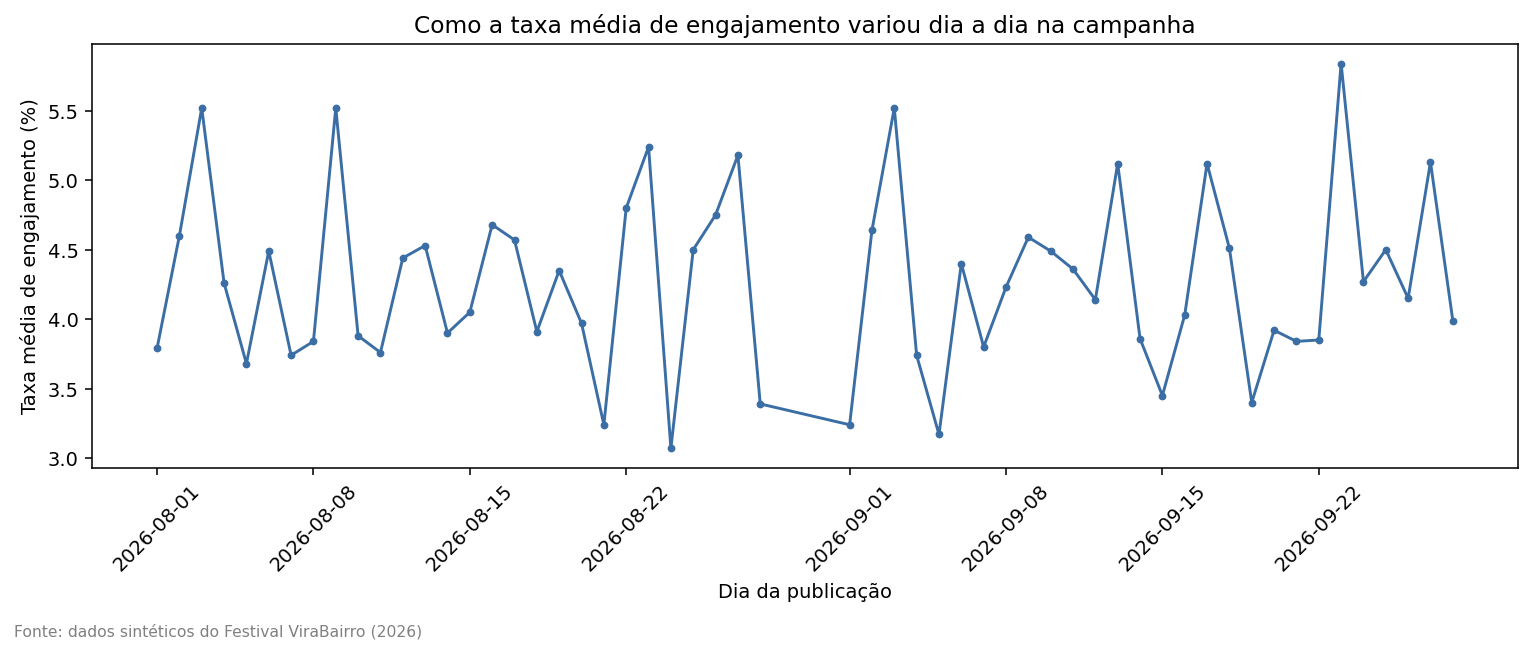

In [12]:
# Questão 4
# Carregue dados/publicacoes_analise.csv em uma nova variável.
# Converta a data, crie dia_publicacao e produza a tabela diária ordenada.
# Faça o gráfico de linhas e o recorte dos cinco reels noturnos com maior taxa.

# ===========================================================================
# QUESTAO 4
# ===========================================================================

# 1. Base em variavel nova, como o enunciado pede.
q4 = pd.read_csv("dados/publicacoes_analise.csv")

# 2. Converter para data/hora e criar a coluna so com a data.
#    .dt.date corta a hora e deixa apenas ano-mes-dia.
q4["data_publicacao"] = pd.to_datetime(q4["data_publicacao"])
q4["dia_publicacao"] = q4["data_publicacao"].dt.date

# 3. Tabela diaria com as TRES agregacoes pedidas, em ordem cronologica.
tabela_diaria = (
    q4.groupby("dia_publicacao")
      .agg(
          publicacoes=("id_publicacao", "count"),              # quantidade
          media_engajamento_pct=("taxa_engajamento_pct", "mean"),  # media
          alcance_total=("alcance", "sum"),                    # total
      )
      .reset_index()
      .sort_values("dia_publicacao")     # cronologica = ordem crescente da data
      .round(2)
)

print(f"A campanha teve publicacoes em {len(tabela_diaria)} dias diferentes.")
print("\nPrimeiros e ultimos dias da tabela:")
print(pd.concat([tabela_diaria.head(3), tabela_diaria.tail(3)]).to_string(index=False))

# 4. Grafico de LINHAS da taxa media por dia.
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.plot(tabela_diaria["dia_publicacao"],
        tabela_diaria["media_engajamento_pct"],
        marker="o", markersize=3, color="#3b6ea5")

ax.set_title("Como a taxa média de engajamento variou dia a dia na campanha")
ax.set_xlabel("Dia da publicação")
ax.set_ylabel("Taxa média de engajamento (%)")
ax.tick_params(axis="x", rotation=45)   # gira as datas para nao sobrepor

fig.text(0.01, -0.02, "Fonte: dados sintéticos do Festival ViraBairro (2026)",
         fontsize=8, color="gray")

fig.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# QUESTAO 4, parte 4: recorte dos reels noturnos
# ---------------------------------------------------------------------------

# Duas condicoes ao mesmo tempo: formato e reel E hora e 18 ou mais.
# Cada condicao entre parenteses, ligadas por &  (nunca "and" aqui).
reels_noturnos = q4[(q4["formato"] == "reel") & (q4["hora"] >= 18)]

print(f"Reels publicados a partir das 18h: {len(reels_noturnos)}")

# As cinco maiores taxas. nlargest(5, "coluna") ja ordena e corta de uma vez.
# Alternativa que da o mesmo resultado: .sort_values("coluna", ascending=False).head(5)
top5_reels = reels_noturnos.nlargest(5, "taxa_engajamento_pct")[
    ["id_publicacao", "dia_publicacao", "hora", "tema", "taxa_engajamento_pct"]
]

top5_reels

### O que os dados mostraram

A campanha tem publicações em **56 dias diferentes**, de 01/08/2026 a 28/09/2026, com um total de 120 publicações. Faça a conta: isso dá cerca de **duas publicações por dia**. A tabela confirma, com 3 por dia no começo e 2 no fim.

Esse número é a chave da questão inteira. Uma média diária calculada sobre duas ou três publicações **não é uma medida estável do dia**: é quase o valor de uma peça só. Todo o serrilhado do gráfico de linhas é, em boa parte, aritmética de amostra pequena, não comportamento do público.

No recorte, **21 reels** foram publicados a partir das 18h, e as cinco maiores taxas são:

| id | dia | hora | tema | taxa |
|---|---|---|---|---|
| OCB-003 | 2026-08-03 | 22 | cultura | 6,82% |
| OCB-107 | 2026-09-23 | 18 | mobilidade | 6,80% |
| OCB-087 | 2026-09-03 | 22 | cultura | 6,15% |
| OCB-097 | 2026-09-13 | 20 | mobilidade | 6,08% |
| OCB-027 | 2026-08-27 | 20 | mobilidade | 5,64% |

Cinco de 21 é quase um quarto do grupo. Selecionar as melhores de um grupo já filtrado e depois usá-las como evidência a favor do filtro é o erro lógico que a questão está testando.

### Resposta da Questão 4

> A taxa média de engajamento oscila de um dia para o outro ao longo de quase dois meses de campanha, alternando picos e quedas sem uma direção estável de subida ou descida. Boa parte dessa oscilação é aritmética e não comportamento do público: a base tem 120 publicações distribuídas em 56 dias, ou seja, duas a três por dia, e com esse tamanho uma única peça acima ou abaixo do padrão desloca a média do dia inteiro. Por isso o gráfico não autoriza nenhuma afirmação sobre tendência de longo prazo, apenas sobre variação diária. O recorte dos cinco reels noturnos com maior taxa também não prova que horário ou formato causem engajamento, porque ele seleciona as cinco melhores de um grupo de apenas 21 publicações que já havia sido filtrado justamente por formato e horário: os casos foram escolhidos pelo resultado que se quer explicar. Para sustentar que reel noturno funciona seria preciso comparar reels noturnos com reels publicados em outros horários e com outros formatos no mesmo horário, mantendo o resto parecido, e essa comparação não foi feita.

### O raciocínio que dá ponto aqui

A questão testa se você entende **por que um ranking não é uma prova**. Olhar os cinco melhores de um grupo e concluir que o grupo é bom é seleção pelo resultado. Para dizer que reel noturno funciona seria preciso comparar reel noturno com reel diurno e com carrossel noturno. A resposta que menciona essa comparação ausente é a que se destaca, porque mostra que você sabe qual seria o teste correto, não só que o atual é insuficiente.

---

# Questão 5: Tema e formato das publicações

### O que a questão pede

Uma tabela com **uma linha para cada combinação de tema e formato**, com número de publicações e mediana de `taxa_engajamento_pct`, ordenada da maior para a menor. Depois um gráfico de barras comparando as combinações, com título, eixos e fonte. Na resposta, de 4 a 6 frases: destacar uma combinação que mereça ser testada, explicar por que comparar duas variáveis é diferente de analisar apenas uma, e registrar uma limitação.

### O que está sendo testado

`groupby` com **duas chaves**. Nas aulas você só agrupou por uma coluna de cada vez. A mudança é mínima e vale ponto inteiro: em vez de passar um nome, passe uma lista.

```python
df.groupby(["tema", "formato"])
```

### A armadilha

**O número de linhas se multiplica.** Quatro temas vezes três formatos dá 12 combinações, e com 12 barras verticais os rótulos viram um borrão. Duas saídas: girar os rótulos com `ax.tick_params(axis="x", rotation=45)`, ou usar **barra horizontal** com `ax.barh()`, que é o que o código abaixo faz porque o nome da combinação é comprido.

**E a coluna `publicacoes` não é decoração.** É ela que te diz em qual linha confiar. Numa base de 120 publicações repartida em 12 caixas, nenhuma caixa vai ter muito.

Combinacoes de tema e formato encontradas: 12
      tema   formato  publicacoes  mediana_engajamento_pct
mobilidade      reel           11                     5.10
   cultura      reel            8                     4.82
     saude      reel           12                     4.67
   cultura carrossel           10                     4.54
mobilidade carrossel           10                     4.53
   cultura    imagem            8                     4.39
     saude carrossel           11                     4.29
  trabalho      reel            8                     4.27
  trabalho carrossel           10                     3.73
mobilidade    imagem           12                     3.60
     saude    imagem           12                     3.38
  trabalho    imagem            8                     3.04
<celula>:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


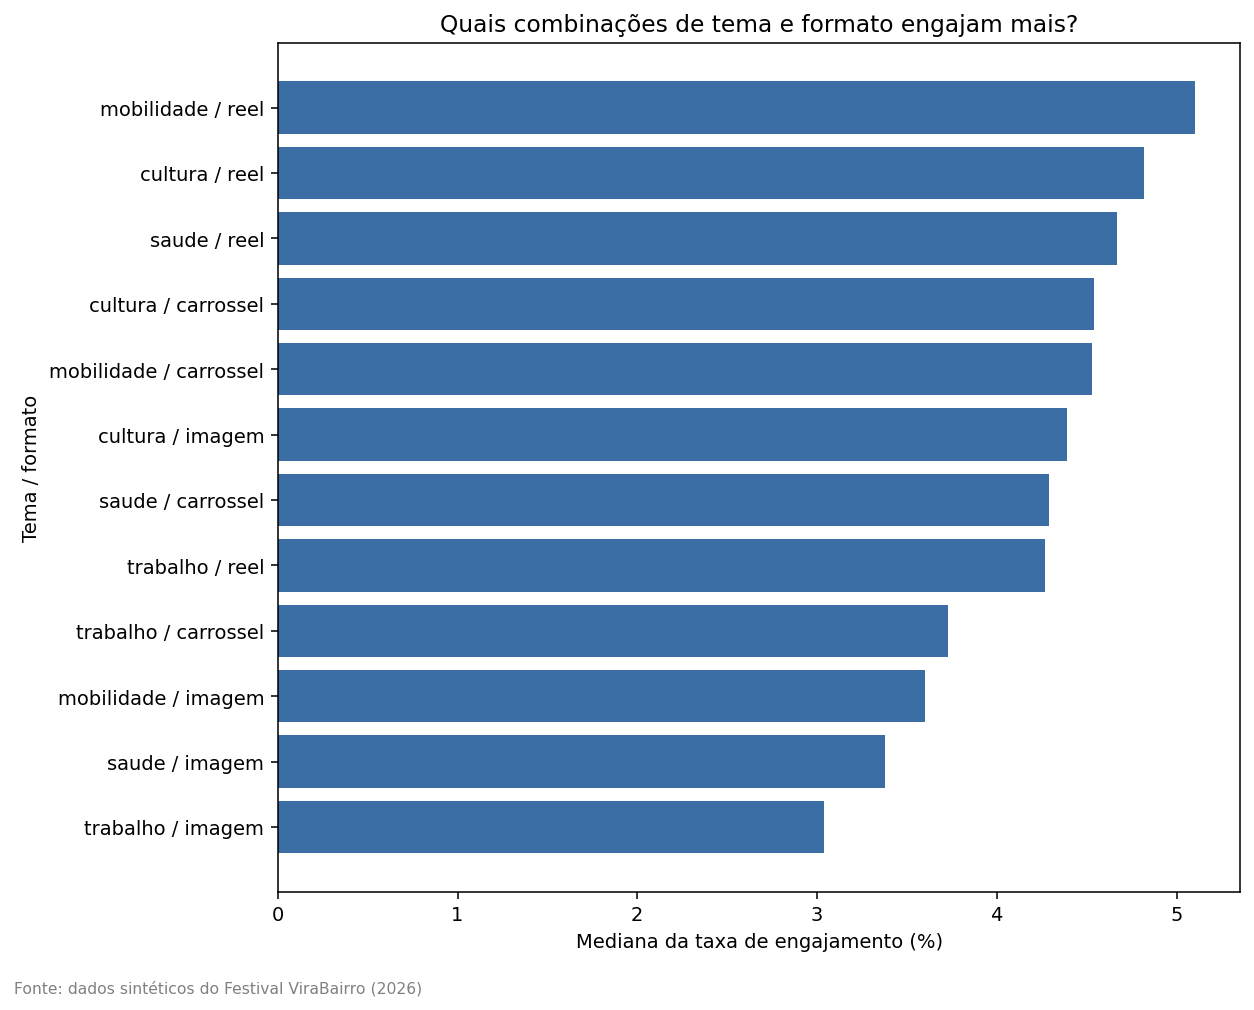

In [14]:
# Questão 5
# Carregue dados/publicacoes_analise.csv em uma nova variável.
# Agrupe por tema e formato, calcule a quantidade de publicações e a mediana de taxa_engajamento_pct.
# Ordene a tabela e faça um gráfico de barras que compare as combinações.
# Inclua título, rótulos dos eixos e a fonte no próprio gráfico.

# ===========================================================================
# QUESTAO 5
# ===========================================================================

q5 = pd.read_csv("dados/publicacoes_analise.csv")

# groupby com DUAS chaves: basta passar uma lista em vez de um nome so.
tabela_q5 = (
    q5.groupby(["tema", "formato"])
      .agg(
          publicacoes=("id_publicacao", "count"),
          mediana_engajamento_pct=("taxa_engajamento_pct", "median"),
      )
      .reset_index()
      .sort_values("mediana_engajamento_pct", ascending=False)
      .round(2)
)

print(f"Combinacoes de tema e formato encontradas: {len(tabela_q5)}")
print(tabela_q5.to_string(index=False))

# ---------------------------------------------------------------------------
# QUESTAO 5, grafico das combinacoes
# ---------------------------------------------------------------------------

# Junto tema e formato num rotulo unico para virar o eixo do grafico.
tabela_q5["combinacao"] = tabela_q5["tema"] + " / " + tabela_q5["formato"]

fig, ax = plt.subplots(figsize=(9, 7))

# barh = barra horizontal. Escolhi horizontal porque sao muitas combinacoes
# e o rotulo e comprido; na vertical os nomes ficariam ilegiveis.
# [::-1] inverte a ordem para a maior mediana aparecer no TOPO do grafico.
ax.barh(tabela_q5["combinacao"][::-1],
        tabela_q5["mediana_engajamento_pct"][::-1],
        color="#3b6ea5")

ax.set_title("Quais combinações de tema e formato engajam mais?")
ax.set_xlabel("Mediana da taxa de engajamento (%)")   # no barh, o valor fica no eixo X
ax.set_ylabel("Tema / formato")

fig.text(0.01, -0.02, "Fonte: dados sintéticos do Festival ViraBairro (2026)",
         fontsize=8, color="gray")

fig.tight_layout()
plt.show()

### O que os dados mostraram

Doze combinações, com **8 a 12 publicações cada**. A tabela completa, da maior para a menor mediana:

| tema | formato | publicações | mediana |
|---|---|---|---|
| mobilidade | reel | 11 | 5,10% |
| cultura | reel | 8 | 4,82% |
| saude | reel | 12 | 4,67% |
| cultura | carrossel | 10 | 4,54% |
| mobilidade | carrossel | 10 | 4,53% |
| cultura | imagem | 8 | 4,39% |
| saude | carrossel | 11 | 4,29% |
| trabalho | reel | 8 | 4,27% |
| trabalho | carrossel | 10 | 3,73% |
| mobilidade | imagem | 12 | 3,60% |
| saude | imagem | 12 | 3,38% |
| trabalho | imagem | 8 | 3,04% |

Agora reorganize essa tabela na cabeça, por tema:

- **cultura:** reel 4,82 > carrossel 4,54 > imagem 4,39
- **mobilidade:** reel 5,10 > carrossel 4,53 > imagem 3,60
- **saude:** reel 4,67 > carrossel 4,29 > imagem 3,38
- **trabalho:** reel 4,27 > carrossel 3,73 > imagem 3,04

**A ordem reel, carrossel, imagem se repete dentro de todos os quatro temas, sem uma única exceção.** Esse é o achado real da questão, e ele não aparece na tabela ordenada por mediana: só aparece quando você reagrupa.

E tem um segundo achado, mais sutil: **o tema que lidera muda conforme o formato.** Entre os reels, mobilidade é o primeiro. Entre carrosséis e imagens, cultura é o primeiro. É exatamente o tipo de coisa que a análise de uma variável só apagaria, e é literalmente o que o enunciado está perguntando quando diz "analisar cada variável separadamente pode ocultar diferenças".

### Resposta da Questão 5

> A combinação de mobilidade em reel aparece no topo da tabela, com mediana de 5,10%, e é a candidata natural a ser testada, com a ressalva de que ela está a 0,28 ponto de cultura em reel e a 0,43 de saúde em reel, diferenças pequenas para combinações que têm entre 8 e 12 publicações cada. O cruzamento revela um padrão que a análise de uma variável isolada esconderia: dentro de cada um dos quatro temas, sem exceção, a ordem é reel, depois carrossel, depois imagem, o que indica que o formato ordena o resultado de forma bem mais consistente do que o tema. Ao mesmo tempo, o tema que lidera muda conforme o formato, já que mobilidade é o primeiro entre os reels enquanto cultura é o primeiro entre carrosséis e imagens. É por isso que comparar duas variáveis juntas é diferente de analisar cada uma isoladamente: olhando só o tema, a vantagem de mobilidade poderia vir apenas de ela concentrar mais reels, e olhando só o formato, perderíamos essa inversão de liderança entre os temas. Como limitação, nenhuma célula da tabela passa de 12 publicações, e uma mediana calculada sobre esse número é instável o bastante para trocar de posição no ranking por causa de uma única peça atípica. Pelo que a base sustenta, a recomendação mais segura é priorizar reel como formato, decisão que se repete em todos os temas, e tratar a escolha do tema como decisão editorial.

Seis frases, o limite que o enunciado dá.

### Por que esta resposta se destaca

Ela responde a pergunta que foi feita (uma combinação para testar) **e** entrega um achado que a pergunta não pediu mas os dados mostram: o formato é o que ordena de forma consistente, o tema não. Esse tipo de leitura, que reorganiza a tabela para enxergar um padrão em vez de só ler a primeira linha, é o que separa uma resposta de nota máxima das outras.

---

# Questão 6: Variáveis mais usadas pela árvore

### O que a questão pede

Criar `mereceu_divulgacao_adicional` pelo **percentil 75** de `taxa_engajamento_pct`; usar apenas as características disponíveis antes da publicação, transformando categorias em números; separar 75% treino e 25% teste com `random_state=42` **preservando a proporção do alvo**; ajustar uma árvore com `max_depth=4`, `random_state=42` e **pesos balanceados**; e produzir tabela e gráfico de barras horizontal com as cinco características mais importantes.

### Traduzindo o enunciado para código

O enunciado usa português, o scikit-learn usa parâmetro. Essa tradução é metade da questão:

| O enunciado diz | Você escreve |
|---|---|
| percentil 75 | `df["coluna"].quantile(0.75)` |
| reserve 75% para treino e 25% para teste | `test_size=0.25` |
| preservando a proporção do alvo | `stratify=y` |
| profundidade máxima 4 | `max_depth=4` |
| pesos balanceados entre as classes | `class_weight="balanced"` |
| gráfico de barras horizontal | `ax.barh(...)` |

### A armadilha número 1 da prova inteira: `pd.get_dummies`

`tema` e `formato` são **texto**. O scikit-learn não aceita texto: se você mandar do jeito que está, ele quebra com `ValueError: could not convert string to float`. A conversão é uma linha:

```python
X = pd.get_dummies(q6[CARACTERISTICAS], columns=["tema", "formato"])
```

Vale um cuidado de preparação: nas aulas 11 e 12 esse comando aparece citado na seção "quando der errado", sem uma célula que o execute, então é provável que você nunca tenha rodado ele. Como o enunciado das questões 6, 7 e 8 pede explicitamente para transformar as categorias em números, escreva e rode esse comando pelo menos uma vez antes da prova. Se você decorar uma linha deste material inteiro, decore essa.

### A armadilha número 2: vazamento de dados

O enunciado lista quais características você pode usar. Não invente. `alcance`, `curtidas`, `comentarios`, `compartilhamentos`, `salvamentos` e a própria `taxa_engajamento_pct` são **resultado**: só existem depois da publicação ir ao ar. Usar qualquer uma para prever é olhar o gabarito. `id_publicacao` também fica de fora, por outro motivo: é só um código, não descreve a peça.

Tudo importado. pandas: 2.3.1
Corte (percentil 75 da taxa): 4.89%
Publicacoes marcadas com 1: 30 de 120 (25%)

Depois do get_dummies, X tem 15 colunas:
['seguidores_autor', 'videos_autor', 'tamanho_legenda', 'n_emojis', 'n_hashtags', 'hora', 'dia_semana', 'duracao_segundos', 'tema_cultura', 'tema_mobilidade', 'tema_saude', 'tema_trabalho', 'formato_carrossel', 'formato_imagem', 'formato_reel']

Treino: 90 publicacoes (26% com alvo 1)
Teste:  30 publicacoes (23% com alvo 1)

Cinco caracteristicas de maior importancia:
caracteristica  importancia
  formato_reel     0.276310
    dia_semana     0.139167
    n_hashtags     0.138668
  tema_cultura     0.099608
  videos_autor     0.094908
<celula>:115: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


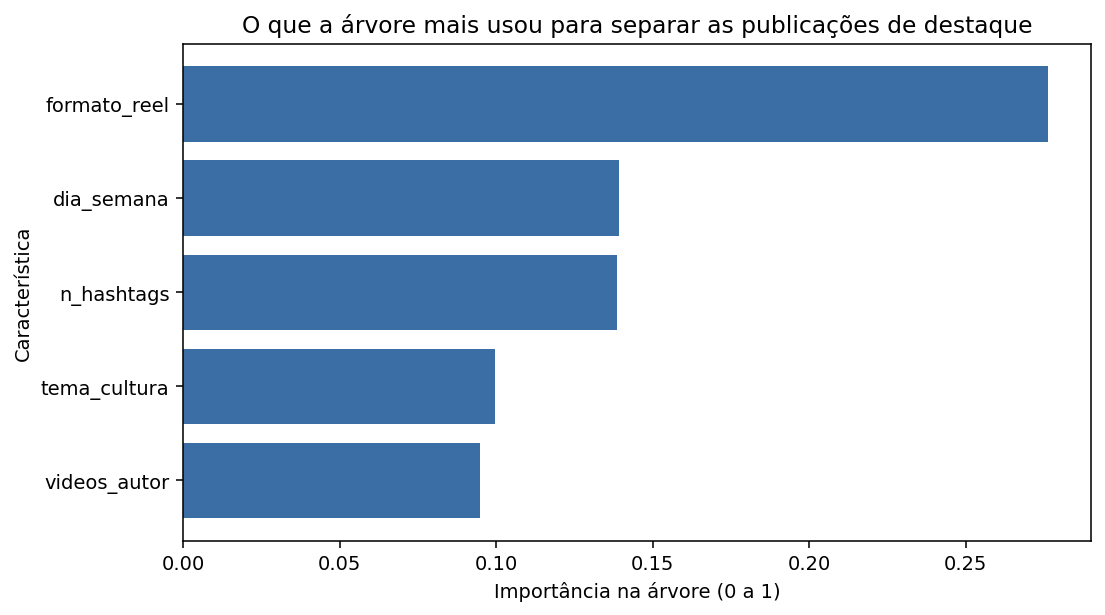

In [17]:
# Questão 6
# Carregue dados/publicacoes_analise.csv, crie o alvo e prepare as características permitidas.
# Ajuste a árvore de classificação solicitada.
# Mostre as cinco maiores importâncias e faça o gráfico horizontal.

# ---------------------------------------------------------------------------
# Imports. Faca todos aqui, uma vez so, no comeco da prova.
# ---------------------------------------------------------------------------
import pandas as pd                 # tabelas (DataFrame). A base de tudo.
import numpy as np                  # operacoes numericas (media, raiz, array)
import matplotlib.pyplot as plt     # graficos

# scikit-learn: separar treino e teste
from sklearn.model_selection import train_test_split

# scikit-learn: modelos de regressao (questao 7)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# scikit-learn: modelos de classificacao (questoes 6 e 8)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# scikit-learn: metricas
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

print("Tudo importado. pandas:", pd.__version__)

# ===========================================================================
# QUESTAO 6
# ===========================================================================

q6 = pd.read_csv("dados/publicacoes_analise.csv")

# ---------------------------------------------------------------------------
# 1. Criar o alvo pelo percentil 75
# ---------------------------------------------------------------------------
corte_p75 = q6["taxa_engajamento_pct"].quantile(0.75)
q6["mereceu_divulgacao_adicional"] = (q6["taxa_engajamento_pct"] > corte_p75).astype(int)

print(f"Corte (percentil 75 da taxa): {corte_p75:.2f}%")
print(f"Publicacoes marcadas com 1: {q6['mereceu_divulgacao_adicional'].sum()} "
      f"de {len(q6)} ({q6['mereceu_divulgacao_adicional'].mean():.0%})")

# ---------------------------------------------------------------------------
# 2. Caracteristicas permitidas (as mesmas listadas na Questao 8)
# ---------------------------------------------------------------------------
# Escrevo a lista uma vez e reaproveito nas questoes 7 e 8.
CARACTERISTICAS = [
    "tema", "formato",            # categoricas: precisam virar numero
    "seguidores_autor", "videos_autor", "tamanho_legenda",
    "n_emojis", "n_hashtags", "hora", "dia_semana", "duracao_segundos",
]

# AQUI esta o comando que as aulas nao demonstraram.
# get_dummies transforma cada categoria de texto numa coluna de 0 e 1.
X = pd.get_dummies(q6[CARACTERISTICAS], columns=["tema", "formato"])
y = q6["mereceu_divulgacao_adicional"]

print(f"\nDepois do get_dummies, X tem {X.shape[1]} colunas:")
print(list(X.columns))

# ---------------------------------------------------------------------------
# 3. Treino e teste, preservando a proporcao do alvo
# ---------------------------------------------------------------------------
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.25,        # "reserve 25% para teste"
    random_state=42,       # sorteio reproduzivel, exigido pelo enunciado
    stratify=y,            # "preservando a proporcao do alvo"
)
print(f"\nTreino: {len(y_treino)} publicacoes ({y_treino.mean():.0%} com alvo 1)")
print(f"Teste:  {len(y_teste)} publicacoes ({y_teste.mean():.0%} com alvo 1)")

# ---------------------------------------------------------------------------
# 4. A arvore, exatamente com os parametros do enunciado
# ---------------------------------------------------------------------------
arvore_q6 = DecisionTreeClassifier(
    max_depth=4,               # "profundidade maxima 4"
    random_state=42,
    class_weight="balanced",   # "pesos balanceados entre as classes"
)
arvore_q6.fit(X_treino, y_treino)

# ---------------------------------------------------------------------------
# 5. As cinco caracteristicas mais importantes
# ---------------------------------------------------------------------------
importancias = pd.DataFrame({
    "caracteristica": X.columns,
    "importancia": arvore_q6.feature_importances_,
}).sort_values("importancia", ascending=False).reset_index(drop=True)

top5_importancias = importancias.head(5)
print("\nCinco caracteristicas de maior importancia:")
print(top5_importancias.to_string(index=False))

# ---------------------------------------------------------------------------
# QUESTAO 6, grafico de barras HORIZONTAL das importancias
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 4.5))

# [::-1] inverte para a caracteristica mais importante ficar no topo
ax.barh(top5_importancias["caracteristica"][::-1],
        top5_importancias["importancia"][::-1],
        color="#3b6ea5")

ax.set_title("O que a árvore mais usou para separar as publicações de destaque")
ax.set_xlabel("Importância na árvore (0 a 1)")
ax.set_ylabel("Característica")

fig.tight_layout()
plt.show()

### O que os dados mostraram

O corte do percentil 75 ficou em **4,89%**, marcando 30 das 120 publicações (25%, como esperado de um percentil 75). O `get_dummies` produziu **15 colunas**, porque esta base tem 3 formatos, não 4. A divisão deixou 90 publicações no treino e 30 no teste.

As cinco maiores importâncias:

| característica | importância |
|---|---|
| formato_reel | 0,276 |
| dia_semana | 0,139 |
| n_hashtags | 0,139 |
| tema_cultura | 0,100 |
| videos_autor | 0,095 |

`formato_reel` no topo bate com o que a questão 5 mostrou: reel é o formato que mais separa desempenho. É um bom sinal quando duas questões independentes apontam para a mesma coisa.

**Mas olhe o segundo e o terceiro lugar: 0,139 e 0,139.** Empate técnico. E a árvore inteira foi treinada com 90 publicações, das quais só 23 são da classe positiva. Com esse tamanho, a ordem entre `dia_semana` e `n_hashtags` não significa nada: trocar o `random_state` provavelmente inverteria as duas. Esse é o material da segunda parte da resposta, que pede "uma mudança na base que poderia alterar esse ranking".

### Resposta da Questão 6

> A árvore usou principalmente `formato_reel`, com importância 0,28, seguido de `dia_semana` e `n_hashtags`, empatados em 0,14, depois `tema_cultura` com 0,10 e `videos_autor` com 0,09. Importância alta significa apenas que a característica foi útil para dividir os dados que a árvore viu no treino, não que ela cause o desempenho: `formato_reel` pode estar no topo porque os reels desta campanha concentram determinados temas, horários e durações, e a árvore aproveita essa associação sem conseguir separar o que vem de quê. A limitação decisiva aqui é o tamanho da base: a árvore foi treinada com 90 publicações, das quais apenas 23 pertencem à classe positiva, e com esse número o ranking é instável. Uma mudança pequena já o alteraria: trocar o `random_state` do `train_test_split`, acrescentar uma dezena de publicações, ou passar a distribuir formatos e horários de maneira mais equilibrada faria `dia_semana` e `n_hashtags`, que hoje empatam na segunda casa decimal, trocarem de posição sem que nada tenha mudado no fenômeno real.

### Por que importância alta não prova causalidade

É a mesma ideia do coeficiente da aula 11. A árvore encontrou que uma característica **anda junto** com engajamento alto nos dados que ela viu. Isso é associação. Para virar causa seria preciso um experimento: publicar peças iguais mudando só aquela característica. A base é observacional, ninguém controlou nada, então tudo o que sai dali é associação.

O detalhe que eleva a resposta é citar o **empate na segunda casa decimal** como prova concreta de instabilidade, em vez de falar em instabilidade de forma abstrata.

---

# Questão 7: Estimativa de engajamento

### O que a questão pede

Dizer qual tipo de aprendizado é adequado e por quê; usar só as características permitidas; 75% treino e 25% teste com `random_state=42`; ajustar uma **regressão linear** e uma **árvore de regressão com `max_depth=4`**, comparando as duas numa tabela de **MAE e R²**; e, para o modelo de menor MAE, um gráfico de dispersão entre valores reais e previstos com uma **linha de referência** onde previsão e valor real seriam iguais.

### A primeira parte é raciocínio, não código

O alvo é `taxa_engajamento_pct`, um **número contínuo**. Número contínuo significa **regressão**. Classificação seria se a pergunta fosse "vai ou não vai passar de tal valor". Clusterização não serve porque não existe alvo a prever: ela só agrupa por semelhança, sem resposta conhecida.

### Cuidado: aqui **não** tem `stratify`

`stratify` serve para manter a proporção entre categorias. Em regressão o alvo é contínuo, não tem categoria para proporcionar. Se você copiar o `train_test_split` da questão 6 com o `stratify=y` junto, o scikit-learn quebra.

### O gráfico de dispersão com linha de referência

Esse gráfico não tem exemplo pronto nos notebooks das aulas, e é simples. Cada ponto é uma publicação do teste, com o valor real no eixo X e o previsto no eixo Y. Se o modelo fosse perfeito, todos os pontos estariam em cima da diagonal onde real é igual a previsto. Você desenha essa diagonal ligando o menor ao maior valor:

```python
minimo = float(min(y_teste.min(), previsao.min()))
maximo = float(max(y_teste.max(), previsao.max()))
ax.plot([minimo, maximo], [minimo, maximo], color="#c0392b", linestyle="--")
```

Ponto acima da linha significa que o modelo previu mais do que aconteceu; abaixo, previu menos. Nuvem larga significa erro grande.

### Uma dica que vale ponto

O **modelo bobo** (prever sempre a média do treino) não foi pedido. Custa duas linhas, e sem ele você não tem como dizer se o seu modelo aprendeu alguma coisa ou não. Um R² de 0,64 parece bom, mas só significa algo comparado a alguma referência.

Treino: 90 publicacoes | Teste: 30 publicacoes

                       modelo   MAE     R2
          modelo bobo (média) 0.603 -0.025
             regressão linear 0.349  0.644
árvore de regressão (prof. 4) 0.516  0.129
Modelo com menor MAE: regressão linear
<celula>:96: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


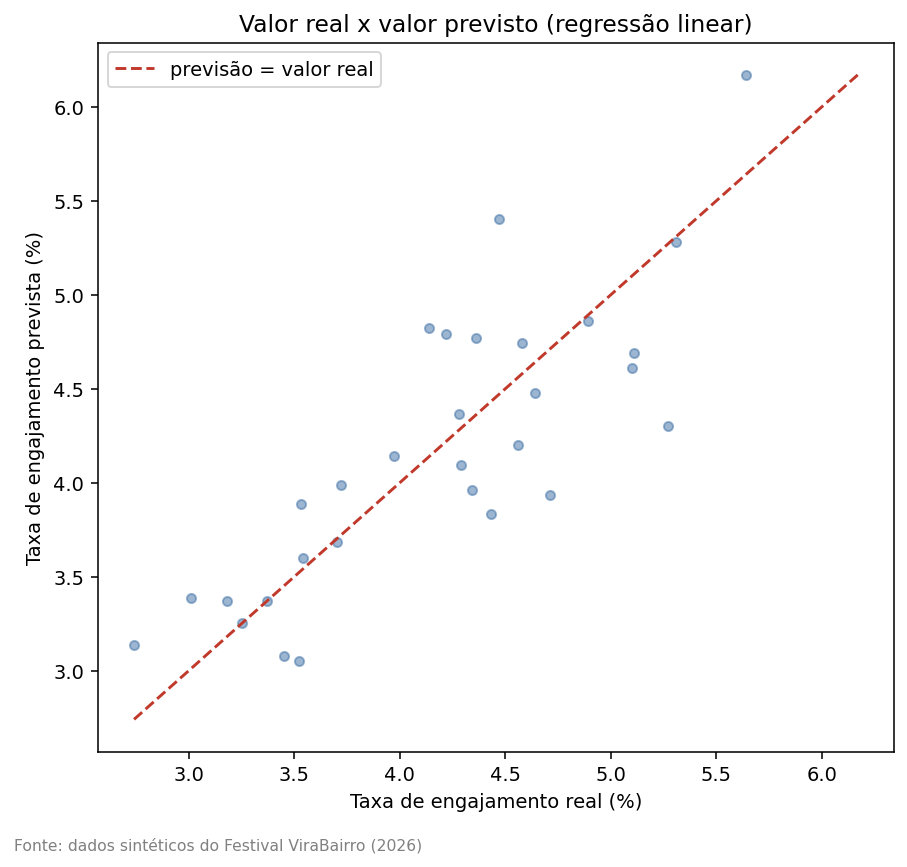

In [18]:
# Questão 7
# Carregue dados/publicacoes_analise.csv em uma nova variável.
# Prepare somente as características permitidas e separe treino e teste.
# Compare regressão linear e árvore de regressão por MAE e R².
# Faça o gráfico de valores reais versus previstos para o modelo com menor MAE.

# ===========================================================================
# QUESTAO 7
# ===========================================================================

q7 = pd.read_csv("dados/publicacoes_analise.csv")

# 1. Mesmas caracteristicas permitidas, mesmo get_dummies da questao 6.
X = pd.get_dummies(q7[CARACTERISTICAS], columns=["tema", "formato"])

# 2. O alvo agora e o NUMERO, nao uma categoria. Isso e regressao.
y = q7["taxa_engajamento_pct"]

# 3. Treino e teste. ATENCAO: sem stratify, porque o alvo e continuo.
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(f"Treino: {len(y_treino)} publicacoes | Teste: {len(y_teste)} publicacoes")

# 4. Os dois modelos pedidos.
modelo_linear = LinearRegression()
modelo_linear.fit(X_treino, y_treino)
previsao_linear = modelo_linear.predict(X_teste)

modelo_arvore = DecisionTreeRegressor(max_depth=4, random_state=42)
modelo_arvore.fit(X_treino, y_treino)
previsao_arvore = modelo_arvore.predict(X_teste)

# 5. "Modelo bobo": prever sempre a media do treino.
#    Nao foi pedido, mas e a referencia que diz se o modelo aprendeu algo.
#    Custa uma linha e rende uma frase forte na resposta escrita.
previsao_boba = np.full(len(y_teste), y_treino.mean())

# 6. Tabela de comparacao com MAE e R2.
comparacao_q7 = pd.DataFrame({
    "modelo": ["modelo bobo (média)", "regressão linear", "árvore de regressão (prof. 4)"],
    "MAE": [
        mean_absolute_error(y_teste, previsao_boba),
        mean_absolute_error(y_teste, previsao_linear),
        mean_absolute_error(y_teste, previsao_arvore),
    ],
    "R2": [
        r2_score(y_teste, previsao_boba),
        r2_score(y_teste, previsao_linear),
        r2_score(y_teste, previsao_arvore),
    ],
}).round(3)

print()
print(comparacao_q7.to_string(index=False))

# ---------------------------------------------------------------------------
# QUESTAO 7, grafico do modelo com MENOR MAE
# ---------------------------------------------------------------------------

# Escolhe automaticamente o de menor MAE entre os dois modelos pedidos,
# assim o grafico continua certo mesmo se na prova o vencedor for o outro.
mae_linear = mean_absolute_error(y_teste, previsao_linear)
mae_arvore = mean_absolute_error(y_teste, previsao_arvore)

if mae_linear <= mae_arvore:
    previsao_escolhida = previsao_linear
    nome_escolhido = "regressão linear"
else:
    previsao_escolhida = previsao_arvore
    nome_escolhido = "árvore de regressão"

print(f"Modelo com menor MAE: {nome_escolhido}")

fig, ax = plt.subplots(figsize=(6.5, 6))

# cada ponto e uma publicacao do conjunto de teste
ax.scatter(y_teste, previsao_escolhida, alpha=0.5, s=22, color="#3b6ea5")

# a linha de referencia: onde previsao seria exatamente igual ao valor real
minimo = float(min(y_teste.min(), previsao_escolhida.min()))
maximo = float(max(y_teste.max(), previsao_escolhida.max()))
ax.plot([minimo, maximo], [minimo, maximo],
        color="#c0392b", linestyle="--", linewidth=1.5,
        label="previsão = valor real")

ax.set_title(f"Valor real x valor previsto ({nome_escolhido})")
ax.set_xlabel("Taxa de engajamento real (%)")
ax.set_ylabel("Taxa de engajamento prevista (%)")
ax.legend()

fig.text(0.01, -0.02, "Fonte: dados sintéticos do Festival ViraBairro (2026)",
         fontsize=8, color="gray")

fig.tight_layout()
plt.show()

### O que os dados mostraram

| modelo | MAE | R² |
|---|---|---|
| modelo bobo (média) | 0,603 | -0,025 |
| **regressão linear** | **0,349** | **0,644** |
| árvore de regressão (prof. 4) | 0,516 | 0,129 |

A regressão linear ganhou, e ganhou com folga: erro 42% menor que o do chute da média, e R² explicando quase dois terços da variação.

**Repare na árvore.** MAE 0,516 contra 0,603 do modelo bobo, e R² de apenas 0,129. Ela mal supera o chute da média. Isso não quer dizer que árvore seja um modelo ruim: quer dizer que, com 90 publicações de treino, ela não tem dados suficientes para aproveitar a flexibilidade que teria. Árvore precisa de volume para encontrar as quebras; regressão linear, com poucas features e poucos dados, se vira melhor.

Isso contraria o que aconteceu na aula 11, onde a árvore ganhou da linear. É uma boa lição contra o decoreba: **não existe modelo que seja sempre melhor.** Você compara e escolhe pelo número, sempre.

### Resposta da Questão 7

> O tipo de aprendizado adequado é a regressão, porque a variável-alvo, `taxa_engajamento_pct`, é um número contínuo e a equipe quer estimar o valor esperado dessa taxa, não classificá-la numa categoria. A classificação responderia a uma pergunta diferente, do tipo "esta peça vai ou não passar de determinado patamar", e ainda exigiria um corte arbitrário; a clusterização não se aplica porque não há alvo a prever, já que ela apenas agrupa registros por semelhança sem usar resposta conhecida. O MAE mede o erro absoluto médio na mesma unidade do alvo: o MAE de 0,349 da regressão linear significa que, em média, a previsão erra a taxa de engajamento em cerca de 0,35 ponto percentual, para cima ou para baixo. Escolhi a regressão linear, que teve o menor MAE, 0,349 contra 0,516 da árvore, e o maior R², 0,644 contra 0,129; comparadas ao modelo que sempre chuta a média do treino, com MAE 0,603, a linear reduz o erro em cerca de 42% enquanto a árvore fica bem perto do chute, o que sugere que 90 publicações de treino são poucas para uma árvore aproveitar sua flexibilidade. Como limitação, o modelo descreve associações observadas nesta campanha específica e não relações causais: as características não foram distribuídas de forma controlada entre as publicações, então alterar uma delas numa nova peça não garante o efeito que o modelo estima.

### Onde a maioria erra aqui

Escrevendo o MAE em abstrato. "O MAE mede o erro médio" não vale nada sozinho: o que vale é **traduzir o número para a unidade do caso**, dizendo que errar 0,349 significa errar cerca de um terço de ponto percentual na taxa. É a diferença entre repetir a definição e mostrar que você entendeu.

---

# Questão 8: Priorização de divulgação

### O que a questão pede

A mais pesada do simulado, com seis partes: dizer qual tipo de aprendizado é adequado e por que os outros dois não servem; criar `mereceu_divulgacao_adicional` com o percentil 75; usar só as características permitidas; treino e teste 75/25 com `random_state=42` e `stratify`; escolher **três classificadores** da lista e comparar precisão, recall e F1, mais a matriz de confusão do melhor F1; e comparar os cortes **0,50 e 0,30** na regressão logística.

### Parte 1: por que classificação

O alvo é 0 ou 1, uma **categoria**. Regressão não serve porque estima um número contínuo, e a decisão da equipe é binária. Clusterização não serve porque agrupa sem resposta conhecida, e aqui a resposta existe: foi construída pela equipe com o percentil 75.

### Parte 5: qual trio escolher

A lista oferece regressão logística, árvore de classificação, Random Forest, Extra Trees, AdaBoost e Gaussian Naive Bayes. Os dois primeiros são os trabalhados na aula 12; os outros quatro seguem exatamente a mesma interface. Use logística e árvore, que você já conhece, e acrescente um terceiro. Random Forest é a escolha natural, e o import é:

```python
from sklearn.ensemble import RandomForestClassifier
```

Se preferir outro: `from sklearn.ensemble import ExtraTreesClassifier`, `from sklearn.ensemble import AdaBoostClassifier`, `from sklearn.naive_bayes import GaussianNB`. Todos usam o mesmo `fit` e `predict`, então trocar de modelo é trocar uma linha.

**A logística é obrigatória**, porque a parte 6 pede o ajuste de corte especificamente nela.

### Parte 6: o corte de decisão

`.predict()` decide com corte fixo em 0,50. Para mexer no corte você precisa da probabilidade:

```python
probabilidade = modelo.predict_proba(X_teste)[:, 1]
decisao_030 = (probabilidade >= 0.30).astype(int)
```

### O vocabulário que você precisa acertar

Aqui o positivo é "merece divulgação adicional":

- **Falso positivo:** a equipe gastou um dos poucos espaços numa publicação que não ia render. Desperdício de recurso escasso.
- **Falso negativo:** uma publicação que ia render ficou sem apoio. Oportunidade perdida.
- **Precisão:** das que o modelo indicou, quantas realmente mereciam.
- **Recall:** das que realmente mereciam, quantas o modelo encontrou.

### Sobre o ConvergenceWarning

A regressão logística **vai** soltar um aviso amarelo dizendo que não convergiu, e isso aconteceu de verdade na execução abaixo. É porque as características estão em escalas muito diferentes (seguidores na casa dos milhares, hora de 0 a 23). **É aviso, não erro: o modelo rodou e os resultados valem.** Aumentar o `max_iter` ajuda. Padronizar com `StandardScaler` resolve de vez, mas não é necessário para a questão.

In [19]:
# Questão 8
# Carregue dados/publicacoes_analise.csv em uma nova variável e crie mereceu_divulgacao_adicional.
# Prepare somente as características permitidas e transforme as categorias quando necessário.
# Faça treino/teste e compare três classificadores escolhidos da lista do enunciado.
# Mostre precisão, recall e F1; depois, exiba a matriz de confusão do modelo com maior F1.
# Compare os cortes 0,50 e 0,30 da regressão logística no mesmo conjunto de teste.

# ===========================================================================
# QUESTAO 8
# ===========================================================================

q8 = pd.read_csv("dados/publicacoes_analise.csv")

# 2. Alvo pelo percentil 75 (mesmo criterio da questao 6)
corte_p75 = q8["taxa_engajamento_pct"].quantile(0.75)
q8["mereceu_divulgacao_adicional"] = (q8["taxa_engajamento_pct"] > corte_p75).astype(int)

# 3. Caracteristicas permitidas, categorias viram numero
X = pd.get_dummies(q8[CARACTERISTICAS], columns=["tema", "formato"])
y = q8["mereceu_divulgacao_adicional"]

# 4. Treino e teste com stratify (alvo e categoria, entao stratify vale aqui)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 5. Tres classificadores da lista do enunciado.
#    A logistica e obrigatoria porque a parte 6 mexe no corte dela.
logistica = LogisticRegression(max_iter=5000)
arvore_q8 = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight="balanced")
floresta = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")

modelos = {
    "regressão logística": logistica,
    "árvore de classificação": arvore_q8,
    "Random Forest": floresta,
}

linhas = []
for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)              # treina
    decisao = modelo.predict(X_teste)           # decide no conjunto de teste
    linhas.append({
        "modelo": nome,
        "precisão": precision_score(y_teste, decisao, zero_division=0),
        "recall": recall_score(y_teste, decisao, zero_division=0),
        "F1": f1_score(y_teste, decisao, zero_division=0),
    })

comparacao_q8 = pd.DataFrame(linhas).sort_values("F1", ascending=False).round(3)
print(comparacao_q8.to_string(index=False))

# ---------------------------------------------------------------------------
# QUESTAO 8, matriz de confusao do modelo com maior F1
# ---------------------------------------------------------------------------

# Pega o nome da primeira linha da tabela, que ja esta ordenada por F1.
nome_melhor = comparacao_q8.iloc[0]["modelo"]
melhor_modelo = modelos[nome_melhor]
decisao_melhor = melhor_modelo.predict(X_teste)

cm = confusion_matrix(y_teste, decisao_melhor)

print(f"Modelo com maior F1: {nome_melhor}")
print()
print("Matriz de confusao:")
print("                      modelo disse 0   modelo disse 1")
print(f"  era 0 (nao merecia):   {cm[0, 0]:>8}         {cm[0, 1]:>8}   <- falsos positivos")
print(f"  era 1 (merecia):       {cm[1, 0]:>8}         {cm[1, 1]:>8}")
print("                              ^ falsos negativos")
print()
print(f"  Verdadeiros negativos (VN): {cm[0, 0]}   |   Falsos positivos (FP): {cm[0, 1]}")
print(f"  Falsos negativos (FN):      {cm[1, 0]}   |   Verdadeiros positivos (VP): {cm[1, 1]}")

# ---------------------------------------------------------------------------
# QUESTAO 8, parte 6: comparar os cortes 0,50 e 0,30 na LOGISTICA
# ---------------------------------------------------------------------------

# predict_proba devolve duas colunas: [prob de ser 0, prob de ser 1].
# A coluna [:, 1] e a probabilidade de merecer divulgacao adicional.
probabilidade = logistica.predict_proba(X_teste)[:, 1]

linhas_corte = []
for corte in [0.50, 0.30]:
    # em vez de usar .predict(), eu mesmo decido a partir da probabilidade
    decisao_corte = (probabilidade >= corte).astype(int)

    vp = int(((decisao_corte == 1) & (y_teste.values == 1)).sum())
    fp = int(((decisao_corte == 1) & (y_teste.values == 0)).sum())
    fn = int(((decisao_corte == 0) & (y_teste.values == 1)).sum())

    linhas_corte.append({
        "corte": corte,
        "precisão": precision_score(y_teste, decisao_corte, zero_division=0),
        "recall": recall_score(y_teste, decisao_corte, zero_division=0),
        "F1": f1_score(y_teste, decisao_corte, zero_division=0),
        "acertos (VP)": vp,
        "alarmes falsos (FP)": fp,
        "deixou passar (FN)": fn,
    })

tabela_cortes = pd.DataFrame(linhas_corte).round(3)
print(tabela_cortes.to_string(index=False))

                 modelo  precisão  recall    F1
    regressão logística      0.75   0.857 0.800
          Random Forest      1.00   0.429 0.600
árvore de classificação      0.50   0.571 0.533
Modelo com maior F1: regressão logística

Matriz de confusao:
                      modelo disse 0   modelo disse 1
  era 0 (nao merecia):         21                2   <- falsos positivos
  era 1 (merecia):              1                6
                              ^ falsos negativos

  Verdadeiros negativos (VN): 21   |   Falsos positivos (FP): 2
  Falsos negativos (FN):      1   |   Verdadeiros positivos (VP): 6
 corte  precisão  recall    F1  acertos (VP)  alarmes falsos (FP)  deixou passar (FN)
   0.5      0.75   0.857 0.800             6                    2                   1
   0.3      0.70   1.000 0.824             7                    3                   0
/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 5000 ite

### O que os dados mostraram

| modelo | precisão | recall | F1 |
|---|---|---|---|
| **regressão logística** | 0,750 | 0,857 | **0,800** |
| Random Forest | 1,000 | 0,429 | 0,600 |
| árvore de classificação | 0,500 | 0,571 | 0,533 |

A logística venceu. E olhe o **Random Forest**: precisão 1,000 com recall 0,429. Ou seja, ele nunca errou quando apostou, mas só encontrou 3 das 7 publicações que mereciam apoio. É a ilustração perfeita de por que precisão sozinha não basta: um modelo que só aposta quando tem certeza absoluta parece perfeito e deixa mais da metade das oportunidades passar.

Matriz de confusão da logística: 21 verdadeiros negativos, **2 falsos positivos**, **1 falso negativo**, 6 verdadeiros positivos.

Comparação dos cortes:

| corte | precisão | recall | F1 | acertos | alarmes falsos | deixou passar |
|---|---|---|---|---|---|---|
| 0,50 | 0,750 | 0,857 | 0,800 | 6 | 2 | 1 |
| 0,30 | 0,700 | **1,000** | **0,824** | 7 | 3 | 0 |

**Aqui aconteceu algo que o roteiro padrão não previa.** Normalmente baixar o corte derruba a precisão de forma perceptível, e você tem que escolher um lado. Neste caso, baixar para 0,30 captura a única publicação que estava escapando (recall vai a 1,000) ao custo de **um único alarme falso a mais**, e a precisão cai só 0,05. O F1 até **sobe**. Ou seja: o corte de 0,30 é melhor pelos dois critérios ao mesmo tempo, e não há trade-off difícil nenhum.

**E a ressalva que precisa estar na resposta:** o conjunto de teste tem 30 publicações, das quais apenas **7 são positivas**. Com 7 positivos, o recall só pode assumir os valores 0, 1/7, 2/7 e assim por diante: cada acerto move a métrica em cerca de 0,14. A diferença entre os dois cortes é de uma publicação. Isso é frágil demais para virar regra.

### Resposta da Questão 8.1: tipo de modelo

> O aprendizado adequado é a classificação, porque a variável-alvo é binária, indicando apenas se a publicação merece ou não divulgação adicional, e a decisão da equipe também é binária. A regressão não responde diretamente a essa decisão porque estima um valor contínuo, que ainda precisaria de um corte arbitrário para virar ação. A clusterização não responde porque agrupa registros por semelhança sem usar nenhuma resposta conhecida, enquanto aqui a resposta existe e foi definida pela própria equipe a partir do percentil 75.

### Resposta da Questão 8: decisão e riscos de erro

> Escolhi a regressão logística, que teve o maior F1 entre os três modelos comparados, com 0,800, e o corte de 0,30 em vez do padrão de 0,50. Um falso positivo significa gastar um dos poucos espaços de divulgação adicional numa publicação que não iria render, desperdiçando um recurso escasso nos dias finais da campanha, e um falso negativo significa deixar sem apoio uma peça que teria bom desempenho, uma oportunidade que não volta antes do festival. No corte padrão de 0,50, o modelo encontrou 6 das 7 publicações que realmente mereciam apoio, com 2 alarmes falsos e 1 deixada passar. Baixando o corte para 0,30, ele passa a encontrar todas as 7, levando o recall a 1,00, ao custo de apenas um alarme falso a mais, e a precisão cai pouco, de 0,75 para 0,70, de modo que o F1 ainda sobe, de 0,800 para 0,824. Como o ganho de recall custou quase nada em precisão, o corte mais baixo é melhor pelos dois critérios ao mesmo tempo, e não um trade-off difícil como normalmente seria. A ressalva importante é que o conjunto de teste tem apenas 30 publicações e 7 positivos, de forma que cada acerto ou erro move o recall em cerca de 0,14 ponto: a vantagem observada para o corte de 0,30 equivale a uma única publicação e não deveria ser tratada como regra estável para as próximas campanhas.

Seis frases, o limite do enunciado.

### Por que esta resposta é forte

Ela faz quatro coisas que a maioria não faz. Cita **números concretos** da tabela em vez de falar em abstrato. Traduz falso positivo e falso negativo para o **contexto do caso**, não para a definição do livro. Percebe que **neste caso específico não houve trade-off**, em vez de recitar o roteiro genérico de "recall sobe, precisão cai". E termina reconhecendo que a vantagem observada **vale uma publicação**, o que mostra que você sabe o tamanho do conjunto em que está pisando.

Se você só escrevesse "escolhi 0,30 porque o recall subiu", teria acertado a decisão e perdido tudo o que vinha junto.

---

# Fechamento: o que levar para a prova

### Os seis erros que mais custam ponto

1. **Esquecer `pd.get_dummies`** nas questões 6, 7 e 8. É o comando cobrado que não tem célula de exemplo nos notebooks das aulas, então é o que menos gente já rodou.
2. **Usar `stratify` na regressão** (questão 7). Só vale para classificação.
3. **Usar `drop_duplicates()` sem `subset="id_publicacao"`** na questão 2, quando o enunciado pediu por id.
4. **Jogar `dayfirst=True` numa coluna que mistura formatos de data.** Não dá erro, dá resposta errada. Confira `.min()` e `.max()` depois de toda conversão de data.
5. **Gráfico sem título, sem nome de eixo ou sem a fonte.** São quatro itens explícitos nas questões 3, 4 e 5. Cada um é ponto.
6. **Responder o Markdown em uma frase genérica.** Metade da nota está ali, e o enunciado diz quantas frases quer. Conte as frases.

### O roteiro de uma questão, na ordem

Ler o enunciado duas vezes e sublinhar cada verbo. Carregar o arquivo em variável nova. Rodar `df.columns` e `df.head()` para conferir o nome exato das colunas. Escrever o código. **Olhar o resultado** e só então escrever a resposta em Markdown, citando os números que apareceram na sua tela.

### O hábito que mais rende nesta prova

Antes de escrever qualquer recomendação, faça duas perguntas ao número que você acabou de calcular:

**Quantos casos tem por trás dele?** Uma mediana sobre 8 publicações não é uma medida, é uma curiosidade.

**Qual é a distância para o segundo colocado?** Se for menor que o ruído que uma peça isolada causaria, você não tem um vencedor, tem um empate.

Essas duas perguntas, aplicadas às questões 3, 5, 6 e 8, produzem sozinhas quase todas as limitações que o enunciado pede.

### A frase que resolve quase toda pergunta de interpretação

> Isto descreve uma associação observada nesta base específica, não uma relação de causa. As características não foram distribuídas de forma controlada entre as publicações, então não é possível afirmar que alterar uma delas produziria o efeito observado.

Entenda a ideia e adapte com as palavras da questão. Não cole a mesma frase oito vezes: o professor percebe.

### Por fim

Este notebook não é gabarito. É um caminho, com números que foram de verdade para a tela. Na prova de vocês os arquivos podem ser outros, os números vão mudar, e a interpretação de vocês pode ser melhor que a minha. O que não muda é a sequência: carregar, conferir, calcular, **olhar o resultado**, e escrever só o que ele permite dizer.

Qualquer dúvida, me chamem antes da prova, não depois.